In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Wolrd Population Data.csv to Wolrd Population Data (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("Wolrd Population Data.csv", thousands=",")
print(df.shape)
df.head()

(234, 12)


,Rank,Country,Population (2024),Yearly Change,Net Change,Density (P/Km²),Land Area (Km²),Migrants (net),Fert. Rate,Med. Age,Urban Pop %,World Share
0,1,India,1450935791,0.89 %,12866195,488,2973190,-630830,2.0,28,37 %,17.78 %
1,2,China,1419321278,-0.23 %,-3263655,151,9388211,-318992,1.0,40,66 %,17.39 %
2,3,United States,345426571,0.57 %,1949236,38,9147420,1286132,1.6,38,82 %,4.23 %
3,4,Indonesia,283487931,0.82 %,2297864,156,1811570,-38469,2.1,30,59 %,3.47 %
4,5,Pakistan,251269164,1.52 %,3764669,326,770880,-1401173,3.5,20,34 %,3.08 %


In [ ]:
df.dtypes

,0
Rank,int64
Country,object
Population (2024),int64
Yearly Change,object
Net Change,int64
Density (P/Km²),int64
Land Area (Km²),int64
Migrants (net),int64
Fert. Rate,float64
Med. Age,int64


In [ ]:
# Strip '%' and convert to float, treating 'N.A.' as missing
for col in ["Yearly Change", "Urban Pop %", "World Share"]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.strip()
        .replace("N.A.", np.nan)
        .astype(float)
    )

df.dtypes

,0
Rank,int64
Country,object
Population (2024),int64
Yearly Change,float64
Net Change,int64
Density (P/Km²),int64
Land Area (Km²),int64
Migrants (net),int64
Fert. Rate,float64
Med. Age,int64


In [ ]:
df.isna().sum()

,0
Rank,0
Country,0
Population (2024),0
Yearly Change,0
Net Change,0
Density (P/Km²),0
Land Area (Km²),0
Migrants (net),0
Fert. Rate,0
Med. Age,0


In [ ]:
df[df["Urban Pop %"].isna()][["Country", "Population (2024)"]]

,Country,Population (2024)
52,Venezuela,28405543
104,Hong Kong,7414909
114,Singapore,5832387
133,Uruguay,3386588
134,Puerto Rico,3242204
152,Bahrain,1607049
161,Réunion,878591
179,Guadeloupe,375106
180,Martinique,343195
199,U.S. Virgin Islands,84905


In [ ]:
df.describe()

,Rank,Population (2024),Yearly Change,Net Change,Density (P/Km²),Land Area (Km²),Migrants (net),Fert. Rate,Med. Age,Urban Pop %,World Share
count,234.000000,2.340000e+02,234.000000,2.340000e+02,234.000000,2.340000e+02,2.340000e+02,234.000000,234.000000,216.000000,234.000000
mean,117.500000,3.487407e+07,0.942393,3.002291e+05,488.683761,5.559568e+05,7.461111e+01,2.332051,31.679487,59.870370,0.427094
std,67.694165,1.383471e+08,1.367075,1.064043e+06,2412.826175,1.691024e+06,1.792969e+05,1.163002,9.810427,23.939106,1.695240
min,1.000000,4.960000e+02,-5.040000,-3.263655e+06,0.000000,0.000000e+00,-1.401173e+06,0.700000,14.000000,0.000000,0.000000
25%,59.250000,4.782600e+05,0.010000,7.525000e+01,38.500000,2.650000e+03,-1.176800e+04,1.500000,23.000000,41.750000,0.010000
50%,117.500000,5.615064e+06,0.860000,1.878150e+04,96.500000,7.972000e+04,-5.045000e+02,2.000000,32.500000,62.000000,0.070000
75%,175.750000,2.346508e+07,1.875000,2.139155e+05,254.000000,4.070800e+05,3.452500e+03,2.975000,40.000000,80.000000,0.287500
max,234.000000,1.450936e+09,5.070000,1.286620e+07,25927.000000,1.637687e+07,1.286132e+06,6.000000,59.000000,100.000000,17.780000


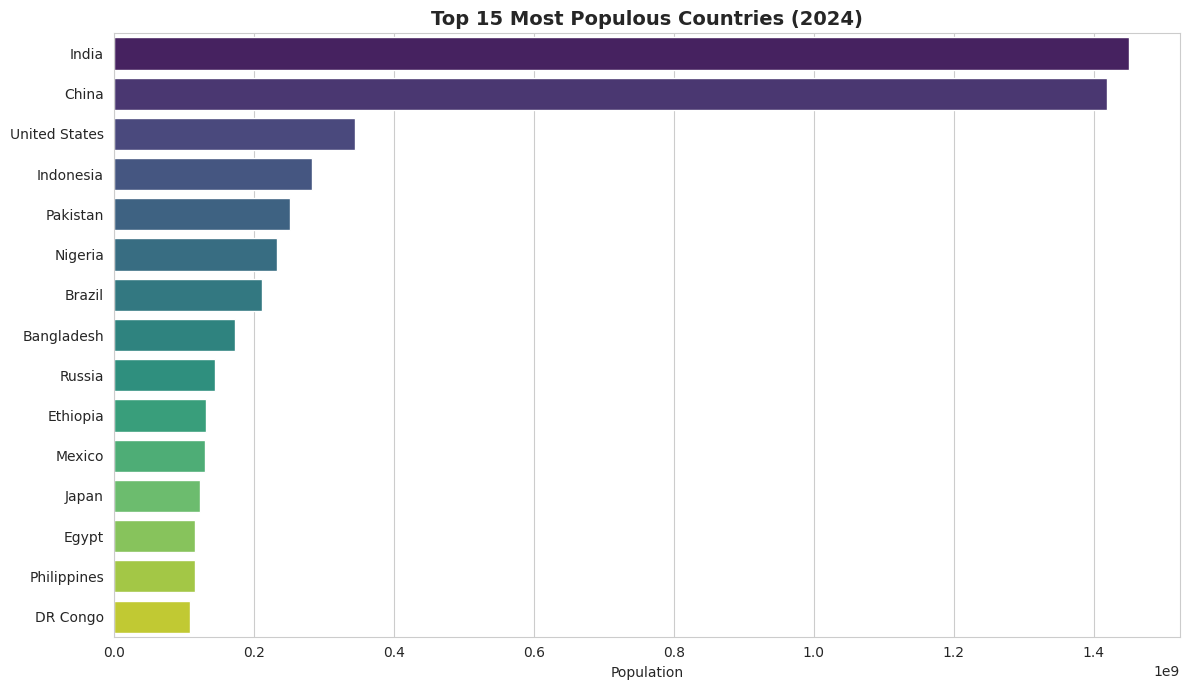

In [ ]:
top15 = df.nlargest(15, "Population (2024)")

plt.figure(figsize=(12, 7))
sns.barplot(data=top15, x="Population (2024)", y="Country", hue="Country", palette="viridis", legend=False)
plt.title("Top 15 Most Populous Countries (2024)", fontsize=14, fontweight="bold")
plt.xlabel("Population")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Insight:** India and China together account for over 1.4B people each, dwarfing the rest of the top 15.
After the top 2, population drops off steadily — the next 13 countries combined don't reach China's total alone.

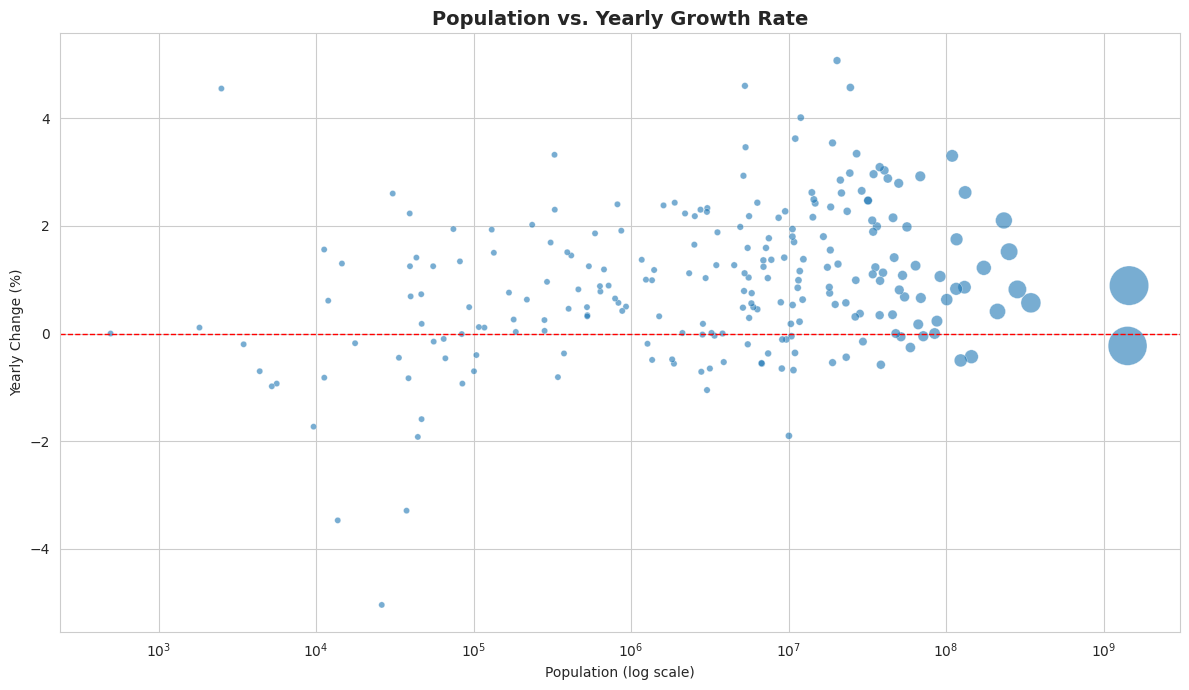

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x="Population (2024)",
    y="Yearly Change",
    size="Population (2024)",
    sizes=(20, 800),
    alpha=0.6,
    legend=False
)
plt.xscale("log")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Population vs. Yearly Growth Rate", fontsize=14, fontweight="bold")
plt.xlabel("Population (log scale)")
plt.ylabel("Yearly Change (%)")
plt.tight_layout()
plt.show()

In [ ]:
print("Fastest growing countries:")
print(df.nlargest(5, "Yearly Change")[["Country", "Population (2024)", "Yearly Change"]])

print("\nFastest shrinking countries:")
print(df.nsmallest(5, "Yearly Change")[["Country", "Population (2024)", "Yearly Change"]])

Fastest growing countries:
         Country  Population (2024)  Yearly Change
64          Chad           20299123           5.07
122         Oman            5281538           4.60
56         Syria           24672760           4.57
231      Tokelau               2506           4.55
80   South Sudan           11943408           4.01

Fastest shrinking countries:
                      Country  Population (2024)  Yearly Change
219              Saint Martin              26129          -5.04
222              Cook Islands              13729          -3.47
216          Marshall Islands              37548          -3.29
210  Northern Mariana Islands              44278          -1.92
94                     Greece           10047817          -1.90


**Insight:** The fastest-growing countries (Chad, Oman, Syria, South Sudan) are driven by high fertility
rates and, in some cases, conflict-related population shifts — not necessarily economic growth.
The fastest-shrinking are mostly small island nations (Saint Martin, Cook Islands, Marshall Islands)
facing emigration, plus Greece, reflecting its well-documented demographic decline since the 2010s debt crisis.

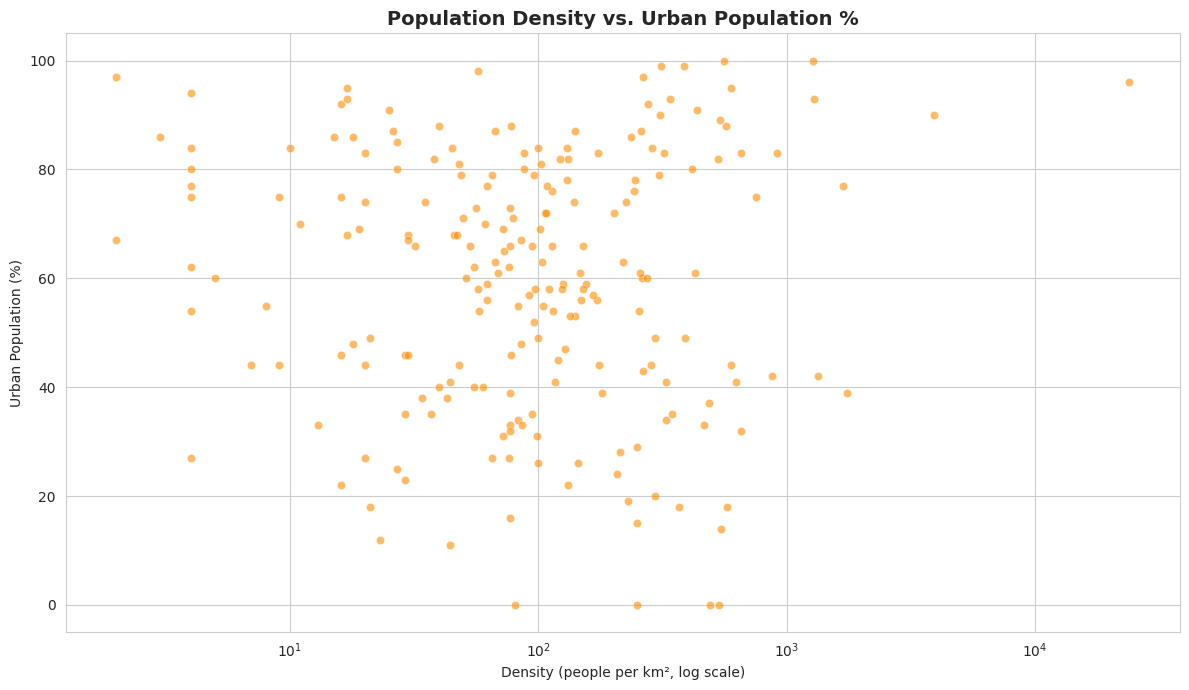

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x="Density (P/Km²)",
    y="Urban Pop %",
    alpha=0.6,
    color="darkorange"
)
plt.xscale("log")
plt.title("Population Density vs. Urban Population %", fontsize=14, fontweight="bold")
plt.xlabel("Density (people per km², log scale)")
plt.ylabel("Urban Population (%)")
plt.tight_layout()
plt.show()

In [ ]:
correlation = df["Density (P/Km²)"].corr(df["Urban Pop %"])
print(f"Correlation between Density and Urban Pop %: {correlation:.3f}")

Correlation between Density and Urban Pop %: 0.116


**Insight:** Density and urbanization show almost no linear correlation (r = 0.116). This makes sense —
density is computed across a country's entire land area (including uninhabited regions), while urban %
reflects only where people choose to live. A country can have vast empty land (low overall density)
while still being highly urbanized (e.g., Australia), or be moderately dense overall while having a large
rural population (e.g., India). These are two distinct dimensions of how people are distributed.

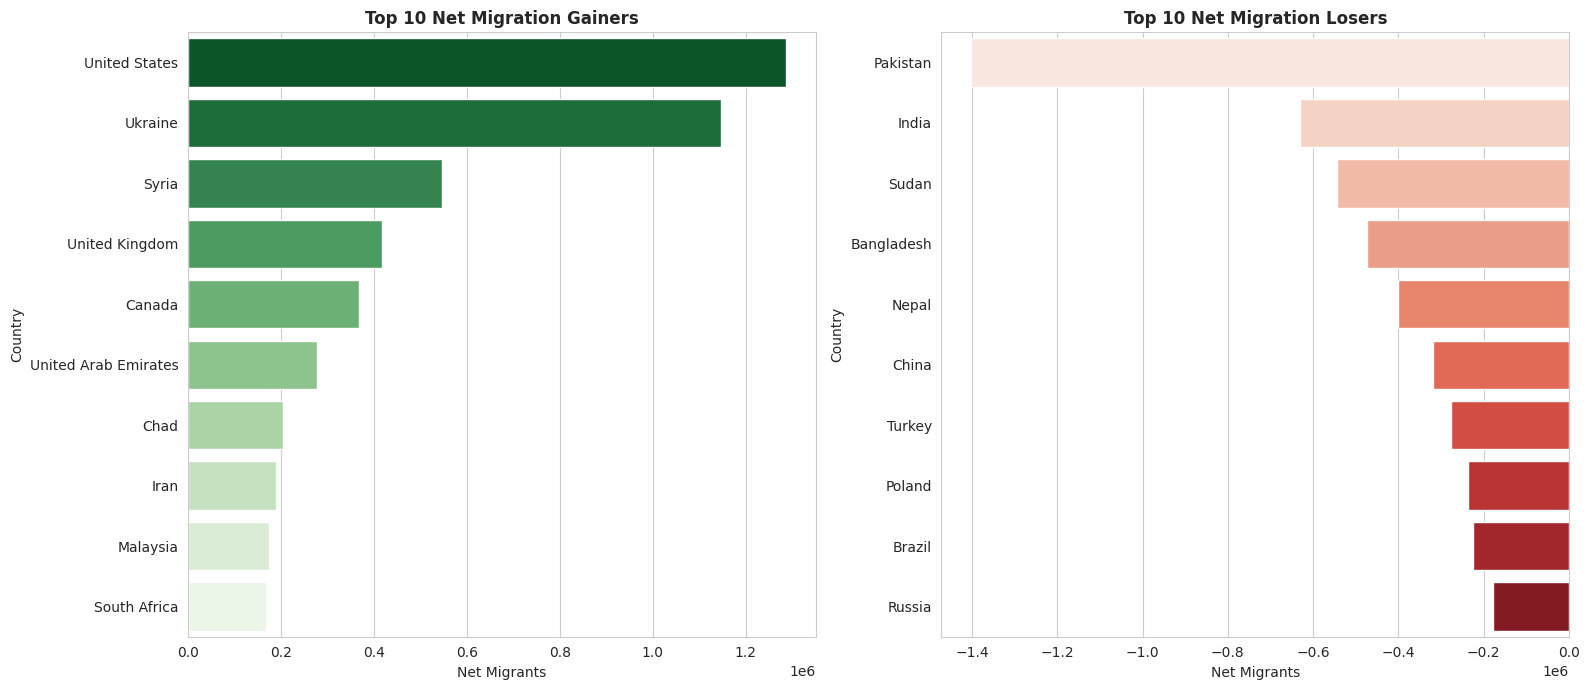

In [ ]:
top_gainers = df.nlargest(10, "Migrants (net)")[["Country", "Migrants (net)"]]
top_losers = df.nsmallest(10, "Migrants (net)")[["Country", "Migrants (net)"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=top_gainers, x="Migrants (net)", y="Country", hue="Country", palette="Greens_r", legend=False, ax=axes[0])
axes[0].set_title("Top 10 Net Migration Gainers", fontweight="bold")
axes[0].set_xlabel("Net Migrants")

sns.barplot(data=top_losers, x="Migrants (net)", y="Country", hue="Country", palette="Reds", legend=False, ax=axes[1])
axes[1].set_title("Top 10 Net Migration Losers", fontweight="bold")
axes[1].set_xlabel("Net Migrants")

plt.tight_layout()
plt.show()

**Insight:** Migration gainers split into two distinct groups: traditional destination economies (US, UK,
Canada, UAE) attracting labor migration, and conflict-recovery countries (Ukraine, Syria) seeing returning
populations — a fundamentally different mechanism. On the losing side, South Asian countries (Pakistan,
India, Bangladesh, Nepal) show large-scale labor emigration, much of which flows toward the Gulf states
seen on the gainers list — the two charts are partially mirror images of the same labor migration pattern.

In [ ]:
features = ["Yearly Change", "Density (P/Km²)", "Fert. Rate", "Med. Age", "Urban Pop %"]

# Drop rows with missing values in these specific columns (only Urban Pop % has NaNs)
cluster_df = df[["Country"] + features].dropna()
print(cluster_df.shape)
cluster_df.head()

(216, 6)


,Country,Yearly Change,Density (P/Km²),Fert. Rate,Med. Age,Urban Pop %
0,India,0.89,488,2.0,28,37.0
1,China,-0.23,151,1.0,40,66.0
2,United States,0.57,38,1.6,38,82.0
3,Indonesia,0.82,156,2.1,30,59.0
4,Pakistan,1.52,326,3.5,20,34.0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[features])

print(X_scaled.shape)
print(X_scaled[:3])  # peek at first 3 rows

(216, 5)
[[-0.1202325   0.10630238 -0.32160776 -0.31125671 -0.95757526]
 [-0.96799256 -0.09704995 -1.16670846  0.95526982  0.25664568]
 [-0.36244966 -0.16523634 -0.65964804  0.74418206  0.92656068]]


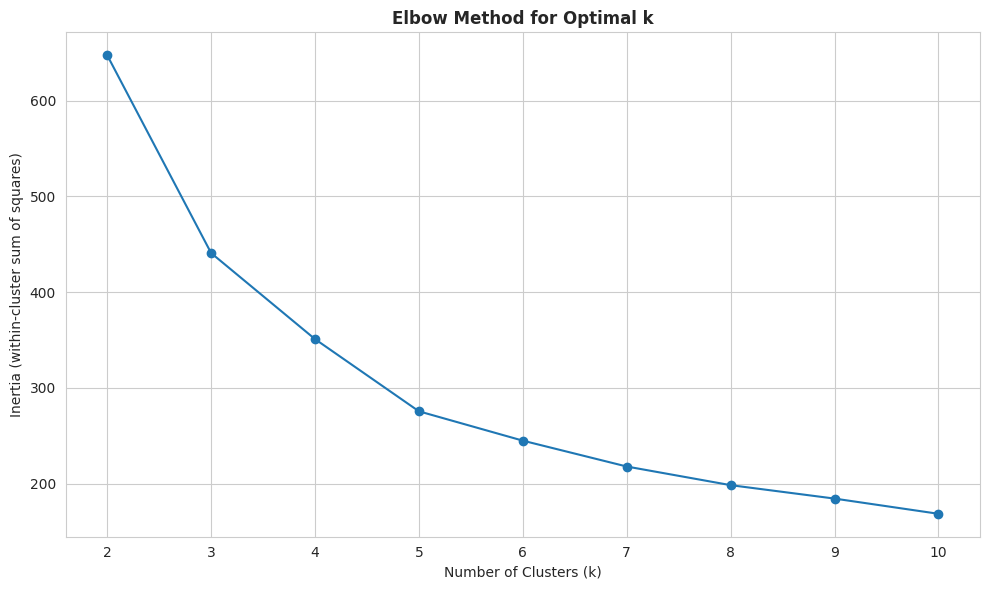

In [ ]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method for Optimal k", fontweight="bold")
plt.xticks(K_range)
plt.tight_layout()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df["Cluster"] = kmeans.fit_predict(X_scaled)

cluster_df["Cluster"].value_counts().sort_index()

,count
Cluster,
0,75
1,1
2,50
3,90


In [ ]:
cluster_df[cluster_df["Cluster"] == 1]

,Country,Yearly Change,Density (P/Km²),Fert. Rate,Med. Age,Urban Pop %,Cluster
166,Macao,0.89,24009,0.7,39,96.0,1


**Insight:** KMeans isolated Macao into its own single-member cluster. With a density of ~24,000
people/km² (roughly 50x the global average) combined with the lowest fertility rate in the dataset (0.7),
Macao's demographic profile is so extreme that it doesn't meaningfully resemble any other country.
Rather than treating this as noise, we keep it as Cluster 1 — it's a legitimate finding that some
city-states are demographic outliers in their own right, not natural fits for broader regional patterns.

In [ ]:
cluster_profile = cluster_df.groupby("Cluster")[features].mean().round(2)
cluster_profile["Count"] = cluster_df["Cluster"].value_counts().sort_index()
cluster_profile

,Yearly Change,Density (P/Km²),Fert. Rate,Med. Age,Urban Pop %,Count
Cluster,,,,,,
0,1.26,218.77,2.33,27.92,65.45,75
1,0.89,24009.00,0.70,39.00,96.00,1
2,2.60,131.02,4.15,18.74,38.90,50
3,0.01,226.53,1.46,40.17,66.47,90


**Cluster Profiles — Demographic Segmentation:**

| Cluster | Name | Growth | Fert. Rate | Med. Age | Urban % | Countries |
|---|---|---|---|---|---|---|
| 2 | Young & Fast-Growing | 2.60% | 4.15 | 18.7 | 38.9% | 50 |
| 0 | Transitioning | 1.26% | 2.33 | 27.9 | 65.5% | 75 |
| 3 | Mature & Slow-Growing | 0.01% | 1.46 | 40.2 | 66.5% | 90 |
| 1 | Macao (Outlier) | 0.89% | 0.70 | 39.0 | 96.0% | 1 |

The three main clusters map closely onto stages of the demographic transition model: Cluster 2 represents
early-transition countries with high fertility and youthful populations (likely concentrated in sub-Saharan
Africa), Cluster 0 represents countries mid-transition with moderate fertility near replacement level, and
Cluster 3 represents late-transition, aging economies with near-zero growth — consistent with much of
Europe and East Asia. This segmentation, derived purely from the data with no regional labels provided,
recovers a well-established demographic framework — a good sign that the clustering captured real structure
rather than noise.

In [ ]:
for c in sorted(cluster_df["Cluster"].unique()):
    countries = cluster_df[cluster_df["Cluster"] == c]["Country"].tolist()
    print(f"\nCluster {c} ({len(countries)} countries):")
    print(", ".join(countries[:15]), "..." if len(countries) > 15 else "")


Cluster 0 (75 countries):
India, Indonesia, Bangladesh, Mexico, Egypt, Philippines, Vietnam, Iran, South Africa, Myanmar, Colombia, Algeria, Iraq, Morocco, Malaysia ...

Cluster 1 (1 countries):
Macao 

Cluster 2 (50 countries):
Pakistan, Nigeria, Ethiopia, DR Congo, Tanzania, Kenya, Sudan, Uganda, Afghanistan, Yemen, Angola, Uzbekistan, Mozambique, Ghana, Madagascar ...

Cluster 3 (90 countries):
China, United States, Brazil, Russia, Japan, Turkey, Germany, Thailand, United Kingdom, France, Italy, South Korea, Spain, Argentina, Canada ...


# Global Population Analysis 2024 — Key Insights

This analysis explores population, growth, density, urbanization, and migration patterns across 234
countries, using UN-style 2024 population data.

**1. Population is heavily concentrated.** India and China alone account for over 1.4 billion people
each — more than the next 13 most populous countries combined.

**2. Size and growth are independent.** Population size does not predict growth rate. Fast-growing
countries (Chad, Oman, Syria, South Sudan) are driven by high fertility and, in some cases, post-conflict
population shifts — not economic expansion. Fastest-shrinking populations are concentrated in small
island nations and Greece, reflecting emigration rather than size.

**3. Density and urbanization are distinct dimensions.** Despite intuition, population density and
urbanization show almost no correlation (r = 0.116) — a country can be sparse overall but highly
urbanized (e.g., Australia), or moderately dense with a large rural population (e.g., India).

**4. Migration reveals two distinct patterns.** Traditional destination economies (US, UK, Canada, UAE)
attract labor migration, while countries like Ukraine and Syria show net gains from returning displaced
populations — a fundamentally different mechanism. Much of the labor emigration from South Asia
(Pakistan, India, Bangladesh) flows toward the same Gulf states appearing as top gainers.

**5. Countries cluster into recognizable demographic stages.** Unsupervised clustering (K-Means, k=4,
chosen via the elbow method) on growth rate, density, fertility, median age, and urbanization recovered
three clear groups that map onto the demographic transition model — Young & Fast-Growing (mostly
sub-Saharan Africa), Transitioning (mixed developing economies), and Mature & Slow-Growing (mostly
Europe and East Asia) — plus Macao as a single-country extreme outlier. Notably, this structure emerged
without providing the model any regional or economic labels.

**Tools used:** Python (pandas, NumPy) for cleaning and analysis, Matplotlib/Seaborn for visualization,
scikit-learn (StandardScaler, KMeans) for clustering.